---
title: Homework Module 1 — Riemann Zeta Function (Partial Sum)
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Executable walkthrough of `HW1_Riemann_Zeta_Function.py`. We approximate

$$
\zeta(s) = \sum_{n=1}^{\infty} n^{-s}
$$

by a **finite sum** of `NUM_TERMS` terms (one million in the assignment). This is fine for integers $s \ge 2$; the series diverges at $s = 1$.

Interactive `input()` is replaced by a hard-coded integer $s$.


## Choose $s$ and the truncation length

In [2]:
# Hard-coded demo (was: input("Input an integer: "))
input_str = "2"
print("Input string:", input_str)
print("Type of input string:", type(input_str))

stripped_str = input_str.strip()
print("Stripped string:", stripped_str)

input_int = int(stripped_str)
print("Input integer s =", input_int)
print("Type of input integer:", type(input_int))

NUM_TERMS = 1_000_000
print(f"Approximating zeta({input_int}) with {NUM_TERMS:,} terms")


Input string: 2
Type of input string: <class 'str'>
Stripped string: 2
Input integer s = 2
Type of input integer: <class 'int'>
Approximating zeta(2) with 1,000,000 terms


## Accumulate the partial sum

$$
\hat\zeta(s) = \sum_{n=1}^{N} \frac{1}{n^{s}}, \quad N = 10^6
$$

In [3]:
# Avoid shadowing Python's built-in sum()
zeta_sum = 0.0

for n in range(1, NUM_TERMS + 1):
    zeta_sum += 1.0 / (n ** input_int)

print(f"Zeta({input_int}) = {zeta_sum:.6f} based on {NUM_TERMS:,} terms")


Zeta(2) = 1.644933 based on 1,000,000 terms


## Sanity checks

For $s = 2$, the exact value is $\zeta(2) = \pi^2/6$ (Basel problem). Compare the partial sum to that closed form.

In [4]:
import math
import numpy as np

if input_int == 2:
    exact = math.pi ** 2 / 6
    print(f"Exact zeta(2) = pi^2/6 = {exact:.10f}")
    print(f"Approximation           = {zeta_sum:.10f}")
    print(f"Absolute error          = {abs(zeta_sum - exact):.2e}")
    print(f"Relative error          = {abs(zeta_sum - exact) / exact:.2e}")

# Show how the partial sum approaches the limit for a few truncations
checkpoints = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
running = 0.0
prev_n = 1
print()
print("Partial sums vs number of terms:")
for N in checkpoints:
    for n in range(prev_n, N + 1):
        running += 1.0 / (n ** input_int)
    prev_n = N + 1
    print(f"  N = {N:>9,}:  zeta~ = {running:.8f}")


Exact zeta(2) = pi^2/6 = 1.6449340668
Approximation           = 1.6449330668
Absolute error          = 1.00e-06
Relative error          = 6.08e-07

Partial sums vs number of terms:
  N =        10:  zeta~ = 1.54976773
  N =       100:  zeta~ = 1.63498390
  N =     1,000:  zeta~ = 1.64393457
  N =    10,000:  zeta~ = 1.64483407
  N =   100,000:  zeta~ = 1.64492407


  N = 1,000,000:  zeta~ = 1.64493307


## Optional plot — convergence for $s=2$

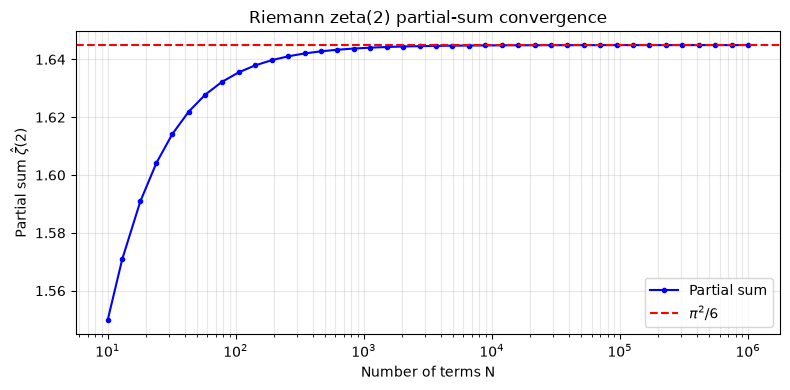

In [5]:
import matplotlib.pyplot as plt

Ns = np.unique(np.logspace(1, 6, 40).astype(int))
partial = []
acc = 0.0
n = 1
for N in Ns:
    while n <= N:
        acc += 1.0 / (n ** 2)
        n += 1
    partial.append(acc)

exact = math.pi ** 2 / 6
plt.figure(figsize=(8, 4))
plt.semilogx(Ns, partial, 'b.-', label='Partial sum')
plt.axhline(exact, color='r', linestyle='--', label=r'$\pi^2/6$')
plt.xlabel('Number of terms N')
plt.ylabel(r'Partial sum $\hat{\zeta}(2)$')
plt.title('Riemann zeta(2) partial-sum convergence')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaways

- Truncated zeta sums are a simple way to meet floating-point / looping objectives in early Python courses.
- For $s=2$, error shrinks slowly (~$1/N$); many terms are needed for high accuracy.
- Original CLI script: `HW1_Riemann_Zeta_Function.py`.